In [49]:
import warnings
warnings.filterwarnings("ignore")

# load data

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd

# Proses ekstraksi data
data = pd.read_csv('/content/drive/MyDrive/[Kompi 2] COMPLETARE/dataset/data_tahunan.csv')

# Tampilkan data
display(data)

,Tahun,listrik_renewable%,co2/ton,grk,co2/gigaton
0,2000,19.991840,281330370,0.60,0.28133
1,2001,20.902410,317027200,0.63,0.31703
2,2002,18.577494,308485920,0.64,0.30849
3,2003,16.883892,339357470,0.67,0.33936
4,2004,16.805578,343021500,0.69,0.34302
5,2005,17.051697,347617020,0.69,0.34762
6,2006,15.347826,346633440,0.73,0.34663
7,2007,16.367926,387858050,0.75,0.38786
8,2008,16.895447,365718300,0.76,0.36572
9,2009,16.448702,398942050,0.79,0.39894


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Tahun               23 non-null     int64  
 1   listrik_renewable%  23 non-null     float64
 2   co2/ton             23 non-null     int64  
 3   grk                 23 non-null     float64
 4   co2/gigaton         23 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 1.0 KB


In [52]:
data1 = data.copy()
df = data1[['Tahun', 'co2/gigaton']]
df

,Tahun,co2/gigaton
0,2000,0.28133
1,2001,0.31703
2,2002,0.30849
3,2003,0.33936
4,2004,0.34302
5,2005,0.34762
6,2006,0.34663
7,2007,0.38786
8,2008,0.36572
9,2009,0.39894


In [53]:
df = df.rename(columns={'co2/gigaton': 'co2'})
df

,Tahun,co2
0,2000,0.28133
1,2001,0.31703
2,2002,0.30849
3,2003,0.33936
4,2004,0.34302
5,2005,0.34762
6,2006,0.34663
7,2007,0.38786
8,2008,0.36572
9,2009,0.39894


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Tahun   23 non-null     int64  
 1   co2     23 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 496.0 bytes


Terlihat kolom tahun type datanya masih int ini perlu di konversi ke type datetime

# Plot Timeseries

In [8]:
# Import library plotly untuk visualisasi data
import numpy as np
import plotly.express as px

def plot_timeseries(
    data : pd.DataFrame,
    value : str,
    judul : str,
    warna : str = 'black',
    showxaxis : bool = False,
    showtrend : bool = False,
):
    fig = px.line(
        data_frame = data,
        x = data.index,
        y = value,
        color_discrete_sequence = [warna]
    )

    if(showtrend):
        # Hitung koefisien regresi linier
        coefficients = np.polyfit(range(len(data)), data[value].fillna(data[value].median()), 1)
        slope = coefficients[0]
        intercept = coefficients[1]

        # Tambahkan garis regresi ke plot
        fig.add_scatter(
            x = data.index,
            y = range(len(data)) * slope + intercept,
            mode = 'lines',
            line = dict(
                color = 'grey',
                dash = 'dash'
            )
        )

    if(showxaxis):
        fig.add_hline(
            y = 0,
            line = dict(
                color = 'LightSeaGreen',
                width = 2,
                dash = 'dash',
            ),
        )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = judul,
            font = dict(
                size = 24,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer = 'colab')

In [9]:
title = f"""
  <b><span style='color:#000435'>Plot data co2/gigaton pertahun</span></b>
"""

plot_timeseries(
    data = df.set_index('Tahun'),
    value = 'co2',
    judul = title,
    warna = '#000435',
    showtrend = False,
)

#Decompose

In [54]:
# Mengonversi kolom 'tahun' menjadi PeriodIndex
df['Tahun'] = pd.to_datetime(df['Tahun'], format='%Y')

# Menetapkan 'tahun' sebagai indeks
df.set_index('Tahun', inplace=True)

In [11]:
# Import library yang dibutuhkan
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Proses dekomposisi musiman
result = seasonal_decompose(
    df['co2']
)

In [12]:
# Definisikan komponen
data_plot = dict(
    data = [pd.DataFrame(result.trend), pd.DataFrame(result.seasonal), pd.DataFrame(result.resid)],
    value = ['trend', 'seasonal', 'resid'],
    color = ['#091057', '#024CAA', '#EC8305'],
    showtrend = [True, False, True]
)

# Lakukan plotting
for i in range(3):
    plot_timeseries(
        data = data_plot.get('data')[i],
        value = data_plot.get('value')[i],
        judul = f"<b><span style='color:{data_plot.get('color')[i]}'>{data_plot.get('value')[i].upper()}</span></b>",
        warna = data_plot.get('color')[i],
        showtrend = data_plot.get('showtrend')[i],
    )

# Stasioneritas

In [13]:
# Import library yang dibutuhkan
from statsmodels.tsa import stattools

def uji_kpss(data, alpha):
    # Proses pengujian kpss
    kpss_test = stattools.kpss(
        data,
        regression = 'c',
        nlags = 'auto'
    )[ : 3]

    # Pengambilan Kesimpulan berdasarkan p-value
    if(kpss_test[1] < alpha):
        kpss_test += ('H0 ditolak', 'Data terindikasi Non-Stasioner')
    else:
        kpss_test += ('H0 diterima', 'Data terindikasi Stasioner')

    # Jadikan dataframe
    output_kpss = pd.DataFrame({
        'Keterangan' : ['Uji Statistik', 'p-value', 'Lags digunakan', 'Hasil Uji', 'Kesimpulan'],
        'Nilai uji' : kpss_test
    })

    return(output_kpss)

In [14]:
# Toleransi error 5%
alpha = 0.05

# Panggil fungsinya
kpss_result = uji_kpss(df['co2'], alpha)

# Tampilkan hasil
display(kpss_result)

,Keterangan,Nilai uji
0,Uji Statistik,0.686939
1,p-value,0.014733
2,Lags digunakan,3
3,Hasil Uji,H0 ditolak
4,Kesimpulan,Data terindikasi Non-Stasioner


# Autocorelation Function

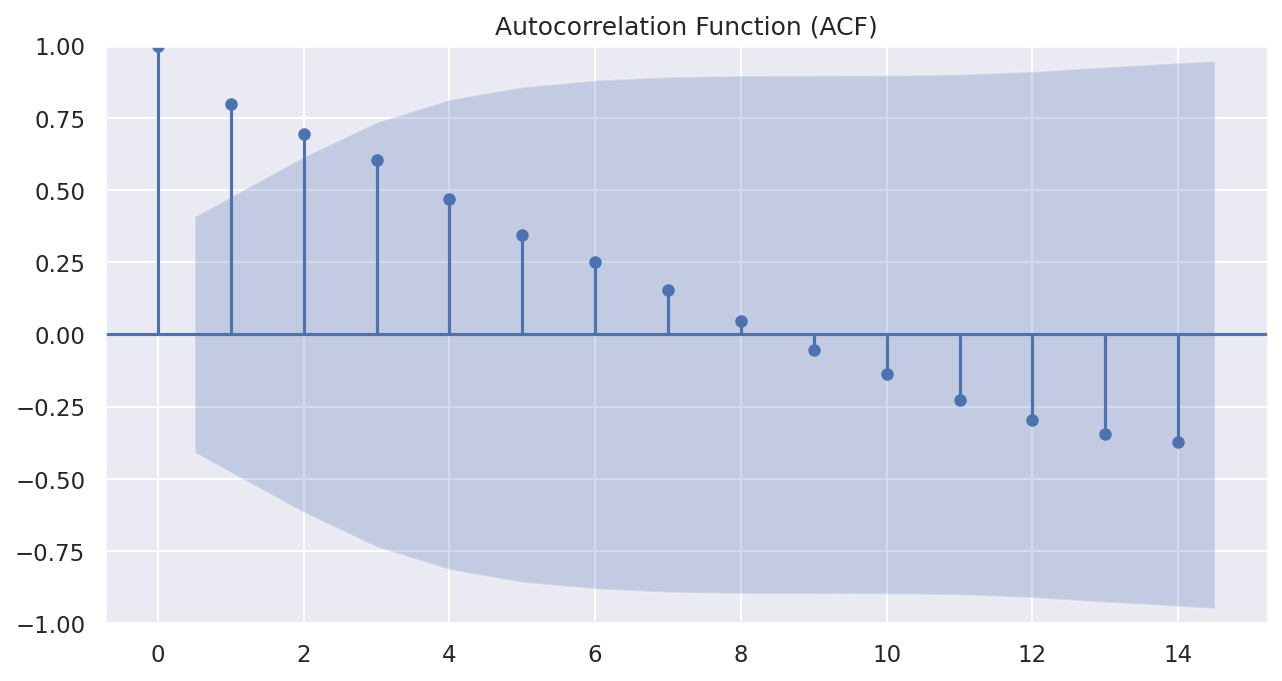

In [15]:
# Import library seaborn dan matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Setting kedalaman kualitas grafik dalam dpi (deep per inch)
sns.set(
    rc = {
        'figure.figsize' : (10, 5),
        'figure.dpi' : 150
    }
)

plot_acf(df[['co2']], lags=14)
plt.title('Autocorrelation Function (ACF)')
plt.show()

Pola Autokorelasi
* Nilai autokorelasi pada lag 1 hingga lag 5 menunjukkan bahwa data memiliki korelasi positif yang signifikan, menandakan adanya ketergantungan jangka pendek dalam data.
* Nilai autokorelasi mulai menurun secara bertahap dan menjadi tidak signifikan (berada dalam area interval kepercayaan, yang diwakili oleh area biru) pada lag yang lebih tinggi (setelah lag 5 atau 6).

kesimpulan
* Data IPM memiliki ketergantungan jangka pendek yang kuat, cocok untuk analisis prediktif berbasis time series.
* Tidak ada pola musiman atau siklus yang kuat.

# split data

In [16]:
# Hitung banyak data
banyak_data = df.shape[0]
print(f'Banyak data = {banyak_data}')

# Inisialisasi proporsi yang digunakan
train_proportion = 0.8
test_proportion = 1 - train_proportion

# Hitung banyak data train dan test
train_size = int(banyak_data * train_proportion)
test_size = banyak_data - train_size

# Tampilkan data
print(f'Banyak data train = {train_size}')
print(f'Banyak data test = {test_size}')

Banyak data = 23
Banyak data train = 18
Banyak data test = 5


In [17]:
# Proses pembagian data
X_train = df.iloc[:train_size]
X_test = df.iloc[train_size:]

# Tampilkan data train
display(X_train)

,co2
Tahun,
2000-01-01,0.28133
2001-01-01,0.31703
2002-01-01,0.30849
2003-01-01,0.33936
2004-01-01,0.34302
2005-01-01,0.34762
2006-01-01,0.34663
2007-01-01,0.38786
2008-01-01,0.36572


In [18]:
# Tampilkan data test
display(X_test)

,co2
Tahun,
2018-01-01,0.59410
2019-01-01,0.65379
2020-01-01,0.60822
2021-01-01,0.61962
2022-01-01,0.73707


# Modeling

## 1. ARIMA (AutoRegressive Integrated Moving Average)

ARIMA dirumuskan :

\begin{equation}
y_t = \mu + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t
\end{equation}

ARIMA(p, d, q) memiliki tiga parameter utama:

* p : Order dari model autoregressive (AR)
* d : Jumlah diferensiasi yang diperlukan untuk membuat data stasioner.
* q : Order dari model moving average (MA).

In [19]:
# Import library plotly untuk visualisasi data
import plotly.express as px

def plot_prediksi(hasil_prediksi, x, y, mae, params = None):
    fig = px.line(
        data_frame = hasil_prediksi,
        x = x,
        y = y,
        color_discrete_sequence = ['#10375C', '#F3C623']
    )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = f"<b>Hasil Prediksi (MAE : {mae})<b><br><sup><sup><span style='color:#000435;font-size:10'>Parameter : {params}</span></sup></sup>",
            font = dict(
                size = 28,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer = 'colab')

###  Pencarian Parameter Terbaik ARIMA

In [20]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
p_values = range(0, 6)  # AR term
d_values = range(0, 6)  # Differencing term
q_values = range(0, 6)  # MA term

# Buat grid search untuk kombinasi parameter (p, d, q)
parameters = list(product(p_values, d_values, q_values))

# Fungsi untuk mengevaluasi model ARIMA
def evaluate_arima_model(train, test, p, d, q):
    try:
        # Fit model ARIMA
        model = ARIMA(train, order=(p, d, q))
        model_fit = model.fit()

        # Prediksi dengan model yang telah dilatih
        forecast = model_fit.forecast(steps = test.shape[0])

        #if(d > 0):
            # Mengembalikan hasil prediksi yang sudah di-differencing ke dalam bentuk asli
        #    forecast = X_train.iloc[-1] + forecast.cumsum()

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['co2',	'predict'],
            mae = round(mae, 4),
            params = f'(p={p}, d={d}, q={q})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# Grid search untuk parameter terbaik
best_mae_ARIMA = float('inf')
best_params_ARIMA = None

for param in parameters:
    p, d, q = param
    mae, forecast = evaluate_arima_model(X_train, X_test, p, d, q)
    if mae < best_mae_ARIMA:
        best_mae_ARIMA = mae
        best_params_ARIMA = param
        best_forecast_ARIMA = forecast

Output hidden; open in https://colab.research.google.com to view.

### Parameter Terbaik ARIMA

In [21]:
# Output hasil terbaik
print(f"Best Parameters (p, d, q): {best_params_ARIMA}")
print(f"Best Mean Absolute Error: {best_mae_ARIMA}")

Best Parameters (p, d, q): (3, 4, 3)
Best Mean Absolute Error: 0.029898563712677427


### Model ARIMA dengan Best Parameter

In [22]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(X_train, order=(best_params_ARIMA[0], best_params_ARIMA[1], best_params_ARIMA[2]))
model_fit = model.fit()

# Ringkasan model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    co2   No. Observations:                   18
Model:                 ARIMA(3, 4, 3)   Log Likelihood                  23.056
Date:                Sat, 23 Nov 2024   AIC                            -32.112
Time:                        06:18:17   BIC                            -27.638
Sample:                    01-01-2000   HQIC                           -32.526
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1456      0.618     -1.854      0.064      -2.357       0.066
ar.L2         -0.7920      1.155     -0.686      0.493      -3.056       1.472
ar.L3         -0.5898      0.674     -0.875      0.3

## 2. Double Exponential Smoothing

DES dirumuskan sebagai :      

\begin{equation}
l_t = \alpha\cdot y_{t} + (1-\alpha)(l_{t-1}+b_{t-1})\\
b_t = \beta(l_{t}-l_{t-1})+(1-\beta)b_{t-1}\\
\hat{y}_{t+k} = l_t + k \cdot b_t
\end{equation}

DES(α, β) memiliki dua parameter utama:

* α : Smoothing Level
* β : Smoothing Trend

### Pencarian Parameter Terbaik DES

In [23]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
alpha = np.arange(0, 1, 0.1)
beta = np.arange(0, 1, 0.1)

# Buat grid search untuk kombinasi parameter
parameters = list(product(alpha, beta))

# Fungsi untuk mengevaluasi model DSE
def evaluate_exponential_smoothing_model(train, test, alpha, beta):
    try:
        # Double Exponential Smoothing (Holt's Linear Trend)
        model = ExponentialSmoothing(train, trend='add', seasonal=None)
        model_fit = model.fit(smoothing_level=alpha, smoothing_trend=beta)

        # Forecast
        forecast = model_fit.forecast(steps=test.shape[0])

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['co2',	'predict'],
            mae = round(mae, 4),
            params = f'(alpha={alpha:.2f}, beta={beta:.2f})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# 4. Grid search untuk parameter terbaik
best_mae_DES = float('inf')
best_params_DES = None

for param in parameters:
    alpha, beta = param
    mae, forecast = evaluate_exponential_smoothing_model(X_train, X_test, alpha, beta)
    if mae < best_mae_DES:
        best_mae_DES = mae
        best_params_DES = param
        best_forecast_DES = forecast

### Parameter Terbaik DES

In [24]:
# Output hasil terbaik
print(f"Best Parameters (alpha, beta): ({best_params_DES[0]:.2f}, {best_params_DES[1]:.2f})")
print(f"Best Mean Absolute Error: {best_mae_DES}")

Best Parameters (alpha, beta): (0.10, 0.90)
Best Mean Absolute Error: 0.03260865746582935


### Model DES dengan Best Parameter

In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ARIMA model
model = ExponentialSmoothing(X_train, trend='add', seasonal=None)
model_fit = model.fit(smoothing_level = best_params_DES[0], smoothing_trend = best_params_DES[1])

# Ringkasan model
print(model_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      co2   No. Observations:                   18
Model:             ExponentialSmoothing   SSE                              0.013
Optimized:                         True   AIC                           -121.937
Trend:                         Additive   BIC                           -118.375
Seasonal:                          None   AICC                          -114.301
Seasonal Periods:                  None   Date:                 Sat, 23 Nov 2024
Box-Cox:                          False   Time:                         06:18:26
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.1000000                alpha                False
smoothing_trend            0.90000

## FB Prophet

In [26]:
X_train = X_train.reset_index()

# Untuk fbprophet kolom tanggal diberi nama ds dan kolom nilai diberi nama y
X_train = X_train.rename(columns = {
    'Tahun' : 'ds',
    'co2' : 'y'
})

### Pencarian Parameter Terbaik FB Prophet

In [27]:
import warnings
warnings.filterwarnings("ignore")
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

# Menentukan parameter grid untuk tuning
param_grid = {
    'daily_seasonality': [False, True],
    'weekly_seasonality': [False, True],
    'yearly_seasonality': [False, True],
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1, 10, 20],
    'seasonality_mode' : ['additive', 'multiplicative'],
}

# Menyimpan hasil
results = list()

# Melakukan grid search
for params in ParameterGrid(param_grid):
    model = Prophet(**params)
    model.fit(X_train)

    # Membuat prediksi
    future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
    forecast = model.predict(future)

    # Menghitung MAE untuk data test
    mae = mean_absolute_error(X_test['co2'], forecast.iloc[train_size:]['yhat'])
    results.append({'params': params, 'mae': mae})

    forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]
    forecast_test['ds'] = forecast_test['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

    hasil_prediksi = X_test.reset_index().merge(forecast_test, left_on = 'Tahun', right_on = 'ds', how = 'left').drop('ds', axis = 1)

    plot_prediksi(
        hasil_prediksi,
        x = 'Tahun',
        y = ['co2', 'yhat'],
        mae = round(mae, 4),
        params = params
    )

    if(len(results) == 1):
        best_mae = mae
        best_params = params
        best_forecast = forecast
    else:
        if(mae < best_mae):
            best_mae = mae
            best_params = params
            best_forecast = forecast

INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/ge1xrs94.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/6hwjcw82.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95192', 'data', 'file=/tmp/tmpn9v8y6cx/ge1xrs94.json', 'init=/tmp/tmpn9v8y6cx/6hwjcw82.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modela2p76zh4/prophet_model-20241123061826.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:18:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:18:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/896gjyl2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/nx2tlapj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76585', 'data', 'file=/tmp/tmpn9v8y6cx/896gjyl2.json', 'init=/tmp/tmpn9v8y6cx/nx2tlapj.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelhjx01dk2/prophet_model-20241123061826.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:18:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:18:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/0qx3a_dh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/5437hbdv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8740', 'data', 'file=/tmp/tmpn9v8y6cx/0qx3a_dh.json', 'init=/tmp/tmpn9v8y6cx/5437hbdv.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_model38a17skx/prophet_model-20241123061827.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:18:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:18:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/p51sa9db.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/mg9h9dzk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61015', 'data', 'file=/tmp/tmpn9v8y6cx/p51sa9db.json', 'init=/tmp/tmpn9v8y6cx/mg9h9dzk.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_model5kfxvpph/prophet_model-20241123061827.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:18:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:18:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/n63thw1b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/x9kovxck.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63386', 'data', 'file=/tmp/tmpn9v8y6cx/n63thw1b.json', 'init=/tmp/tmpn9v8y6cx/x9kovxck.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelc80ejwcc/prophet_model-20241123061827.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:18:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:18:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


...

INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/pgff0ykd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/g2cfyix4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63722', 'data', 'file=/tmp/tmpn9v8y6cx/pgff0ykd.json', 'init=/tmp/tmpn9v8y6cx/g2cfyix4.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_model7exs42av/prophet_model-20241123062449.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:24:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/vnnlfy8a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/kkfewh0s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95178', 'data', 'file=/tmp/tmpn9v8y6cx/vnnlfy8a.json', 'init=/tmp/tmpn9v8y6cx/kkfewh0s.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelg4jwsl2d/prophet_model-20241123062506.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:25:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/z51nuyr9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/tykbsy9h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28133', 'data', 'file=/tmp/tmpn9v8y6cx/z51nuyr9.json', 'init=/tmp/tmpn9v8y6cx/tykbsy9h.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_model59n1dj09/prophet_model-20241123062506.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:25:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/_w4ydd5c.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/ew0pzxbe.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73181', 'data', 'file=/tmp/tmpn9v8y6cx/_w4ydd5c.json', 'init=/tmp/tmpn9v8y6cx/ew0pzxbe.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_model8i57a3p4/prophet_model-20241123062507.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:25:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/lewhszed.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/3kzri0bx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69120', 'data', 'file=/tmp/tmpn9v8y6cx/lewhszed.json', 'init=/tmp/tmpn9v8y6cx/3kzri0bx.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelg28mxlyd/prophet_model-20241123062515.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:25:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


### Parameter Terbaik FB Prophet

In [28]:
print(best_params)

{'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': True, 'yearly_seasonality': True}


In [29]:
# Output hasil terbaik
print(f"Best Parameters FB Prophet: {best_params}")
print(f"Best Mean Absolute Error: {best_mae}")

Best Parameters FB Prophet: {'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1, 'weekly_seasonality': True, 'yearly_seasonality': True}
Best Mean Absolute Error: 0.026660716617748804


### Model FB Prophet dengan Best Parameter

In [32]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

model = Prophet(
    changepoint_prior_scale = 0.01,
    daily_seasonality = True,
    seasonality_mode = 'additive',
    seasonality_prior_scale = 1,
    weekly_seasonality = True,
    yearly_seasonality = True
)

model.fit(X_train)

# Membuat prediksi
future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
forecast = model.predict(future)

forecast['ds'] = forecast['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

# Menghitung MAE untuk data test
mae = mean_absolute_error(X_test['co2'], forecast.iloc[train_size:]['yhat'])

forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]

INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/e9x8ds_1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/bdk7ttqu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53850', 'data', 'file=/tmp/tmpn9v8y6cx/e9x8ds_1.json', 'init=/tmp/tmpn9v8y6cx/bdk7ttqu.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelxdnsqwch/prophet_model-20241123062625.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:26:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:26:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [33]:
print(mae)

0.026660716617748804


# FInal Model

<h1> model terbaik FB PROPHET untuk Emisi CO2


## Model FB Prophet

In [55]:
df2 = df.copy()

df2 = df2.reset_index()

# Untuk fbprophet kolom tanggal diberi nama ds dan kolom nilai diberi nama y
df_model = df2.rename(columns = {
    'Tahun' : 'ds',
    'co2' : 'y'
})

In [56]:
df_model

,ds,y
0,2000-01-01,0.28133
1,2001-01-01,0.31703
2,2002-01-01,0.30849
3,2003-01-01,0.33936
4,2004-01-01,0.34302
5,2005-01-01,0.34762
6,2006-01-01,0.34663
7,2007-01-01,0.38786
8,2008-01-01,0.36572
9,2009-01-01,0.39894


In [61]:
model = Prophet(
    changepoint_prior_scale = 0.01,
    daily_seasonality = True,
    seasonality_mode = 'additive',
    seasonality_prior_scale = 1,
    weekly_seasonality = True,
    yearly_seasonality = True
)


model.fit(df_model)


# Prediksi untuk 6 tahun ke depan (2024-2030)
future = model.make_future_dataframe(periods=8, freq='Y')
forecast = model.predict(future)


INFO:prophet:n_changepoints greater than number of observations. Using 17.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/mne1gxq7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpn9v8y6cx/1j7bv2b9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59375', 'data', 'file=/tmp/tmpn9v8y6cx/mne1gxq7.json', 'init=/tmp/tmpn9v8y6cx/1j7bv2b9.json', 'output', 'file=/tmp/tmpn9v8y6cx/prophet_modelo185cq0n/prophet_model-20241123063211.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:32:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:32:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [102]:
# Tambahkan kolom 'type' untuk membedakan data historis dan prediksi
df_model['type'] = 'actual'
# Sesuaikan forecast pada tanggal yang sama dengan actual pertama (2022-01-01)
forecast['ds'] = pd.to_datetime(forecast['ds'])  # pastikan tipe data tanggal pada forecast adalah datetime
forecast_first_date = pd.to_datetime('2022-01-01')

# Pastikan nilai forecast pada 2022-01-01 sama dengan nilai actual
forecast.loc[forecast['ds'] == forecast_first_date, 'yhat'] = df_model.loc[df_model['ds'] == forecast_first_date, 'y'].values[0]
forecast['type'] = 'forecast'

# Terapkan penyesuaian tanggal jika perlu (contohnya menambah satu hari pada tanggal 31)
forecast['ds'] = forecast['ds'].apply(lambda x: x + timedelta(days=1) if x.day == 31 else x)

# Filter forecast yang sesuai dengan tanggal setelah atau sama dengan 2022-01-01
forecast_filtered = forecast[forecast['ds'] >= forecast_first_date]

# Gabungkan data historis dan prediksi
full_forecast = pd.concat([
    df_model[['ds', 'y', 'type']],  # Data historis
    forecast_filtered[['ds', 'yhat', 'type']].rename(columns={'yhat': 'y'})  # Data forecast
])

# Set index pada kolom 'tahun'
full_forecast.set_index('ds', inplace=True)

In [104]:
full_forecast.rename(columns={'ds': 'tahun', 'y': 'co2'}, inplace=True)
full_forecast

,co2,type
ds,,
2000-01-01,0.281330,actual
2001-01-01,0.317030,actual
2002-01-01,0.308490,actual
2003-01-01,0.339360,actual
2004-01-01,0.343020,actual
2005-01-01,0.347620,actual
2006-01-01,0.346630,actual
2007-01-01,0.387860,actual
2008-01-01,0.365720,actual


In [105]:
import plotly.express as px
import plotly.graph_objects as go

# Plot garis data historis dan prediksi
fig = px.line(
    data_frame=full_forecast,  # Rename kolom hanya untuk visualisasi
    x=full_forecast.index,
    y='co2',
    color='type',
    color_discrete_map={
        'actual': '#0000FF',  # Biru untuk data historis
        'forecast': '#FFD700'  # Kuning untuk data prediksi
    }
)

# Tambahkan titik pertama (data historis awal)
fig.add_trace(
    go.Scatter(
        x=[full_forecast.index[0]],  # Tetap gunakan indeks asli
        y=[full_forecast.iloc[0]['co2']],  # Kolom asli
        mode='markers',
        marker=dict(size=10, color='#0000FF'),
        name='Start Point'
    )
)

# Anotasi untuk titik awal
fig.add_annotation(
    x=full_forecast.index[0],  # Tetap gunakan indeks asli
    y=full_forecast.iloc[0]['co2'],  # Kolom asli
    text = f"Tahun 2010, co2 Indonesia masih 0.28133",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

# Tambahkan titik akhir (prediksi terakhir)
fig.add_trace(
    go.Scatter(
        x=[full_forecast.index[-1]],
        y=[full_forecast.iloc[-1]['co2']],
        mode='markers',
        marker=dict(size=10, color='#FFD700'),
        name='End Point'
    )
)

# Anotasi untuk prediksi terakhir
fig.add_annotation(
    x=full_forecast.index[-1],
    y=full_forecast.iloc[-1]['co2'],
    text = f"2030 Tahun Mendatang,<br> co2 di Indonesia diprediksi akan terus meningkat<br>"\
            "jika dilihat dari tren data sebelumnya<br>",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

# Tambahkan pengaturan layout
fig.update_layout(
    width = 1200,
    height = 500,
    showlegend = False,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    title = dict(
        text = f"<br><b>Apakah di Tahun 2030, <br><span style='color:#000B58;'> Tren CO2 akan terus meningkat?</span>?",
        font = dict(
            size = 17,
            color = '#757882'
        ),
        y = 0.92,
        x = 0.5
    ),
    yaxis = dict(
        title = '',
        showgrid = False,
        showline = False,
        showticklabels = False,
        zeroline = False,
    ),
    margin = dict(
        t = 80,
        b = 10,
        r = 20
    )
)


fig.show(renderer = 'colab')



In [106]:
full_forecast.to_csv('MODEL DATA CO2.csv', index=True)